# 03 - VHI Crop Health Monitoring

Computes **VCI** (from MODIS NDVI vs 2001-present climatology), **TCI** (from MODIS LST), and **VHI = 0.5*VCI + 0.5*TCI**. Produces fortnightly state time-series, drought/heat stress classification (VHI < 40), and a heat-stress hotspot overlay.

In [1]:
import sys, yaml
sys.path.append('..')
import ee, pandas as pd
from src import gee_utils, indices, visualization

with open('../config/config.yaml') as f:
    cfg = yaml.safe_load(f)
gee_utils.init_ee()
SEASON_YEAR = 2023
VHI_CFG = cfg['vhi']

E:\codes\Gitlab project\wheat-crop-monitoring\venv\lib\site-packages\google\api_core\_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# Multi-year climatology (2001 -> season start) for min/max normalisation
states_fc = gee_utils.get_states_fc(cfg['states'])
aoi = states_fc.geometry()
clim_start = f"{VHI_CFG['climatology_start_year']}-01-01"
ndvi_clim = gee_utils.get_modis_ndvi(aoi, clim_start, f'{SEASON_YEAR}-10-31')
lst_clim = gee_utils.get_modis_lst(aoi, clim_start, f'{SEASON_YEAR}-10-31')
print('Climatology images - NDVI:', ndvi_clim.size().getInfo(), '| LST:', lst_clim.size().getInfo())

Climatology images - NDVI: 525 | LST: 1049


## Fortnightly VHI per state

In [4]:
start = ee.Date(f'{SEASON_YEAR}-11-01')
n_fortnights = 12  # Nov -> Apr

# Define list of fortnight indices
fortnight_indices = ee.List.sequence(0, n_fortnights - 1)

# Map over fortnights to get a FeatureCollection per fortnight
def calculate_fortnight_vhi(i):
    i = ee.Number(i)
    f0 = start.advance(i.multiply(15), 'day')
    f1 = f0.advance(15, 'day')
    
    ndvi_now = gee_utils.get_modis_ndvi(aoi, f0, f1).mean()
    lst_now = gee_utils.get_modis_lst(aoi, f0, f1).mean()
    
    vci = indices.compute_vci(ndvi_now, ndvi_clim)
    tci = indices.compute_tci(lst_now, lst_clim)
    vhi = indices.compute_vhi(vci, tci, VHI_CFG['alpha'])
    
    # Spatial reduction: mean VHI for all states
    state_means = vhi.reduceRegions(
        collection=states_fc,
        reducer=ee.Reducer.mean(),
        scale=1000
    )
    
    date_str = f0.format('YYYY-MM-dd')
    
    # Map over states to add date and clean name
    def format_feature(f):
        return f.set({
            'date': date_str,
            'state': f.get('ADM1_NAME'),
            'VHI': f.get('mean')
        })
    
    return state_means.map(format_feature)

# Flatten list of feature collections into a single feature collection
results_fc = ee.FeatureCollection(fortnight_indices.map(calculate_fortnight_vhi)).flatten()

# Pull all records in one single getInfo() call
results = results_fc.select(['date', 'state', 'VHI']).getInfo()

# Build Pandas DataFrame
rows = [feat['properties'] for feat in results['features']]
vhi_df = pd.DataFrame(rows)
vhi_df['date'] = pd.to_datetime(vhi_df['date'])
vhi_df.to_csv('../outputs/vhi_fortnightly.csv', index=False)
vhi_df.head()

,VHI,date,state
0,56.775311,2023-11-01,Bihar
1,57.660006,2023-11-01,Madhya Pradesh
2,50.566065,2023-11-01,Uttar Pradesh
3,61.183728,2023-11-01,Gujarat
4,43.461573,2023-11-01,Haryana


<Axes: title={'center': 'Vegetation Health Index — fortnightly'}, ylabel='VHI'>

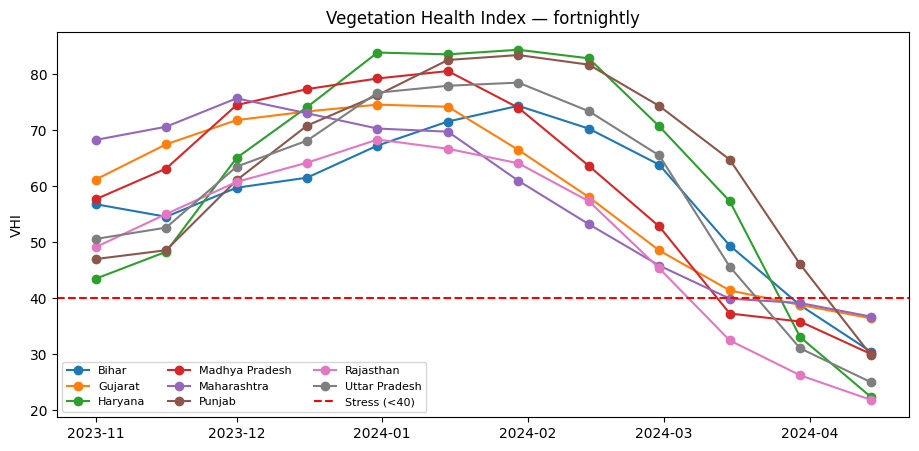

In [5]:
visualization.vhi_timeseries(vhi_df, stress_threshold=VHI_CFG['stress_threshold'])

## Heat stress anomaly hotspot overlay
LST anomaly vs climatology mean, masked to stressed pixels (VHI < 40). Operationally, fuse with **IMD real-time temperature forecasts** (`src.io_utils.load_imd_netcdf`) to anticipate terminal heat stress in Feb-Mar.

In [6]:
# Latest fortnight
f0 = start.advance((n_fortnights - 1) * 15, 'day')
f1 = f0.advance(15, 'day')
ndvi_now = gee_utils.get_modis_ndvi(aoi, f0, f1).mean()
lst_now = gee_utils.get_modis_lst(aoi, f0, f1).mean()
vhi_now = indices.compute_vhi(indices.compute_vci(ndvi_now, ndvi_clim),
                              indices.compute_tci(lst_now, lst_clim), VHI_CFG['alpha'])
lst_anom = lst_now.subtract(lst_clim.mean()).rename('LST_anom')
hotspots = lst_anom.updateMask(indices.vhi_stress_mask(vhi_now, VHI_CFG['stress_threshold']))

import geemap
m = geemap.Map(center=[26.5, 78.0], zoom=5)
m.addLayer(vhi_now.clip(aoi), {'min': 0, 'max': 100, 'palette': ['red', 'yellow', 'green']}, 'VHI')
m.addLayer(hotspots.clip(aoi), {'min': 0, 'max': 8, 'palette': ['orange', 'darkred']}, 'Heat stress hotspots')
m.addLayer(states_fc.style(color='black', fillColor='00000000'), {}, 'States')
m

Map(center=[26.5, 78.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [7]:
# Fortnightly bulletin summary table (latest fortnight, per state)
latest = vhi_df[vhi_df.date == vhi_df.date.max()].copy()
latest['condition'] = pd.cut(latest.VHI, [0, VHI_CFG['severe_threshold'], VHI_CFG['stress_threshold'], 100],
                             labels=['Severe stress', 'Stressed', 'Normal/Good'])
latest.sort_values('VHI')

,VHI,date,state,condition
95,21.838195,2024-04-14,Rajasthan,Severe stress
92,22.380705,2024-04-14,Haryana,Severe stress
90,25.003311,2024-04-14,Uttar Pradesh,Stressed
94,29.887079,2024-04-14,Punjab,Stressed
89,30.034894,2024-04-14,Madhya Pradesh,Stressed
88,30.458010,2024-04-14,Bihar,Stressed
91,36.404739,2024-04-14,Gujarat,Stressed
93,36.707572,2024-04-14,Maharashtra,Stressed
